<a href="https://colab.research.google.com/github/qaiserxd/machine_learning_scikit_learn/blob/master/titanic_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

In [ ]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


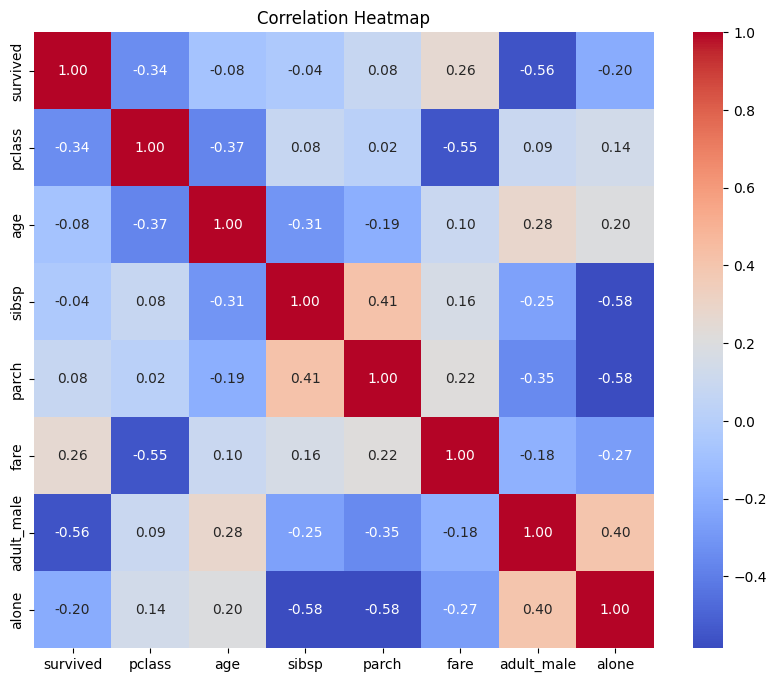

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df = df.drop(columns=["deck", "embark_town", "alive", "class"], errors="ignore")

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

le_sex = LabelEncoder()
df["sex"] = le_sex.fit_transform(df["sex"])
le_embarked = LabelEncoder()
df["embarked"] = le_embarked.fit_transform(df["embarked"])
le_who = LabelEncoder()
df["who"] = le_who.fit_transform(df["who"])

df["adult_male"] = df["adult_male"].astype(int)
df["alone"] = df["alone"].astype(int)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,1,22.0,1,0,7.2500,2,1,1,0
1,1,1,0,38.0,1,0,71.2833,0,2,0,0
2,1,3,0,26.0,0,0,7.9250,2,2,0,1
3,1,1,0,35.0,1,0,53.1000,2,2,0,0
4,0,3,1,35.0,0,0,8.0500,2,1,1,1


In [ ]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
logreg = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=7)
svm = SVC(kernel="linear", random_state=42)

logreg.fit(X_train, y_train)
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)

In [ ]:
print("\nLogistic Regression:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logreg):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_logreg):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_logreg):.4f}")

print("\nKNN:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_knn):.4f}")

print("\nSVM:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm):.4f}\n")


Logistic Regression:
Accuracy:  0.8101
Precision: 0.7857
Recall:    0.7432
F1-score:  0.7639

KNN:
Accuracy:  0.7430
Precision: 0.7500
Recall:    0.5676
F1-score:  0.6462

SVM:
Accuracy:  0.8045
Precision: 0.7826
Recall:    0.7297
F1-score:  0.7552



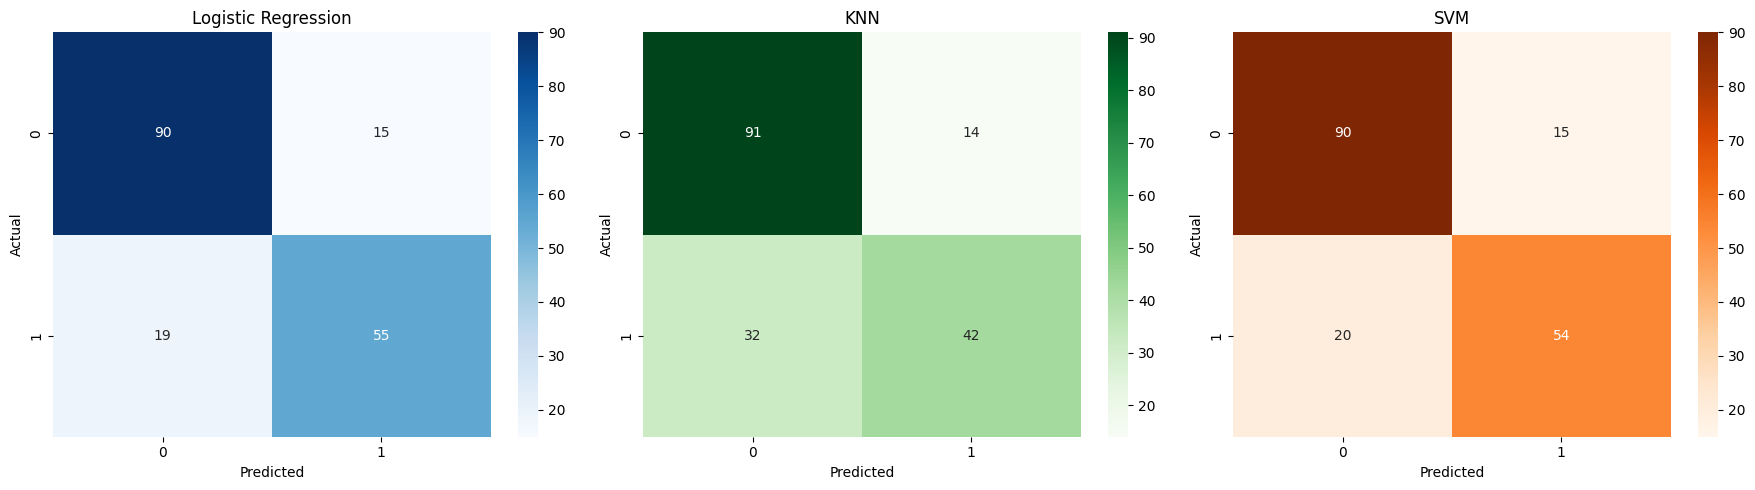

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_logreg),
    annot=True,
    fmt="d",
    ax=axes[0],
    cmap="Blues",
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", ax=axes[1], cmap="Greens"
)
axes[1].set_title("KNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt="d",
    ax=axes[2],
    cmap="Oranges",
)
axes[2].set_title("SVM")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

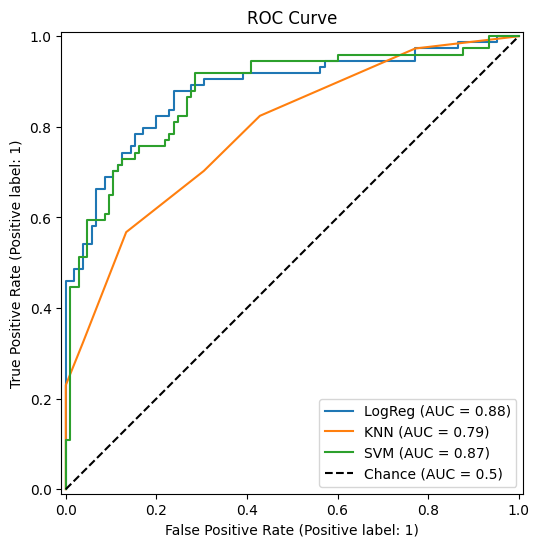

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(logreg, X_test, y_test, ax=ax, name="LogReg")
RocCurveDisplay.from_estimator(knn, X_test, y_test, ax=ax, name="KNN")
RocCurveDisplay.from_estimator(svm, X_test, y_test, ax=ax, name="SVM")

ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.5)")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")
plt.show()